# Homework 9


**Concepts covered:**

matplotlib, line charts, pie chart, histogram, scatterplot

**Instructions:**

Be sure to run each code block after you edit it to make sure it runs as expected. When you are done, we strongly recommend you run all the code from scratch (Runtime menu -> Restart and Run all) to make sure your current code works for all problems.

If your code raises an exception when run from scratch, it will interfere with the auto-grader process causing you to lose some or all points for this homework. Please ask for help on Piazza, attend office hours or schedule an appointment with your learning facilitator if you get stuck.

**Warning about AI:**

While we encourage you to use AI to generate practice problems, **we recommend against using generative AI in the strongest terms** to solve any part of this assignment. The goal of this assignment is for you to learn these concepts, and while using AI may help you obtain solutions to these problems, you will cheat yourself out of the learning that comes from working through the problems yourself.



**Docstrings and Comments:**

Include a *documentation string* (docstring) for each function definition, as well as comments in the body of your code to explain each control structures (e.g., decision, loop), function call, or formula.


## Shared Imports

Run the cell below to import modules that will be used through out
this homework notebook. Do not import any other modules.
In particular, other charting modules such as Seaborn are not allowed.

In [460]:
# shared imports
import math
import numpy as np
import matplotlib.pyplot as plt


**NOTE: Use the appropriate and optimal ranges for the axis values so that the visualizations are not too small.**


**This homework is partially autograded. The plots will be manually graded so please allow some time for you to get a full score.**

**Problem 1 (review)**

**Concept:** *NumPy arrays, math functions*

**Task:**

Write three functions that generate numerical arrays using NumPy.

Each function takes three parameters:

* **start** – the starting value of the array

* **stop** – the ending value of the array (not inclusive)

* **steps** – the increment between values in the array (the step size used by `np.arange`)

Use `np.arange(start, stop, steps)` to generate the base array of values. Then apply the requested NumPy math function to the entire array.

**Functions to Implement:**

1. `generate_sine_wave(start, stop, steps)`

* Generate a NumPy array of values from `start` to `stop` using `np.arange`.
* Compute the sine of each value using `np.sin`.
* Return the array of sine values.
2. `generate_logs(start, stop, steps)`
* Generate a NumPy array of values from `start` to `stop` using `np.arange`.
* Compute the natural logarithm of each value using `np.log`.
* Return the array of log values.
3. `generate_rounded(start, stop, steps)`
* Generate a NumPy array of values from `start` to `stop` using `np.arange`.
* Round each value using `np.round`.
* Return the rounded array.



In [461]:
np.arange(1,20,1)

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19])

In [462]:
# Your Solution

def main():
    ''' 
    A helper function that exacutes functions in proper order.
    '''
    print(f"Base array: {np.arange(0,21,2)}")
    print(f"Generate_sine_wave result: {generate_sine_wave(1, 20, 1)}")
    print(f"Generate_logs result: {generate_logs(1, 20, 1)}")
    print(f"Generate_rounded: {generate_rounded(1, 20, 1)}")

def generate_sine_wave(start, stop, steps):
    ''' 
    A function generate_sine_wave returns the array of sine values.
    '''
    ar = np.arange(start, stop, steps)
    return np.sin(ar)

def generate_logs(start, stop, steps):
    ''' 
    A function generate_logs returns the array of log values.
    '''
    ar = np.arange(start, stop, steps)
    return np.log(ar)

def generate_rounded(start, stop, steps):
    ''' 
    A function generate_rounded returns the array of rounded values.
    '''
    ar = np.arange(start, stop, steps)
    return np.round(ar)

main()


Base array: [ 0  2  4  6  8 10 12 14 16 18 20]
Generate_sine_wave result: [ 0.84147098  0.90929743  0.14112001 -0.7568025  -0.95892427 -0.2794155
  0.6569866   0.98935825  0.41211849 -0.54402111 -0.99999021 -0.53657292
  0.42016704  0.99060736  0.65028784 -0.28790332 -0.96139749 -0.75098725
  0.14987721]
Generate_logs result: [0.         0.69314718 1.09861229 1.38629436 1.60943791 1.79175947
 1.94591015 2.07944154 2.19722458 2.30258509 2.39789527 2.48490665
 2.56494936 2.63905733 2.7080502  2.77258872 2.83321334 2.89037176
 2.94443898]
Generate_rounded: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19]


**Problem 2 (review)**

**Concept:** *reading CSV file, create an np.array of numbers*

**Task:**

Write a function `read_csv_to_dict(filename)` that reads a CSV file and stores the data in a dictionary.

Your function should:
1. Open the CSV file.
2. Read the first row to obtain column headers.
3. Store each column of data as a NumPy array.
4. Use the column names as keys in the dictionary.
5. Return the dictionary.

Each key should correspond to one column in the CSV file.

Example structure:

```
{
   "open": np.array([...]),
   "close": np.array([...]),
   "volume": np.array([...])
}
```


In [ ]:
#Your Solution (This is a hard question :))

# It can be better to use csv module. It comes with function called reader whose purpose in life is 
# to read CSV file for us and figure out, where are the commas, quotes, other potential
# corner cases, and just deal with them for us
# Reader returns lists and DictReader returns Dictionaries, one at a time.
# To use Dict, we have to have Headers in our file!


def read_csv_to_dict(filename):
    ''' 
    A function read_csv_to_dict reads the CSV data and store the data in a dictionary.
    '''
    with open(filename, "r") as f:
        # Header extraction, but next(reader) with csv module is a cleaner solution
        header = f.readline().strip().split(",")

        # Initialize dictionary with empty lists
        data = {key: [] for key in header}

        # Process rows
        for line in f:
            values = line.strip().split(",")
            # key and value are both lists with alligning values
            # So we can zip them together
            for key, value in zip(header, values):
                 try:
                     # We are adding to a list!
                     data[key].append(int(value))
                 except ValueError:
                     try:
                         data[key].append(float(value))
                     except ValueError:
                         data[key].append(value) 

        return {k: np.array(v) for k, v in data.items()}



In [464]:
read_csv_to_dict("data3.csv")
 

{'age': array([22, 62, 42, 49, 49, 60, 59, 62, 18, 64]),
 'height_cm': array([183, 168, 150, 163, 129, 171, 181, 136, 144, 189]),
 'weight_kg': array([51, 57, 98, 90, 98, 90, 65, 83, 67, 73])}

**Problem 3**

**Concepts:** *matplotlib, plt line*

**Task:**

Use NumPy and Matplotlib to generate and plot sine and cosine waves.

Complete the following steps:

1. Create a range of values from **0 to 20** using `np.arange`.
2. Compute:
* the sine wave
* the cosine wave

Create four plots:
1. Plot the **sine wave** by itself.
2. Plot the **cosine wave** by itself.
3. Plot **both waves together on the same chart** with a legend.
4. Compute the **ratio of sine to cosine** and plot it.

Each chart should include a **title**, and the combined chart should include a **legend**.


**Plot 1:**

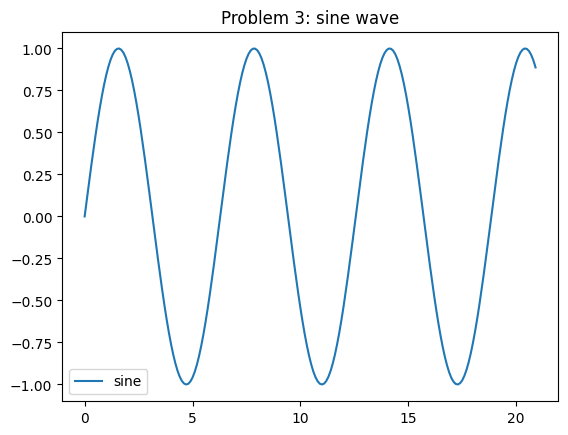

In [465]:
#Your Solution
numbers = np.arange(0,21,.1)
plt.plot(numbers, np.sin(numbers), label = "sine")
plt.legend()
plt.title("Problem 3: sine wave")
plt.show()

**Plot 2:**

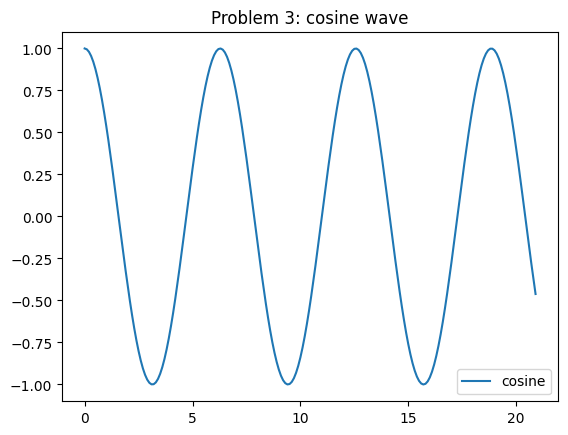

In [466]:
#Your Solution
numbers = np.arange(0,21,.1)
plt.plot(numbers, np.cos(numbers), label = "cosine")
plt.legend()
plt.title("Problem 3: cosine wave")
plt.show()

**Plot 3:**

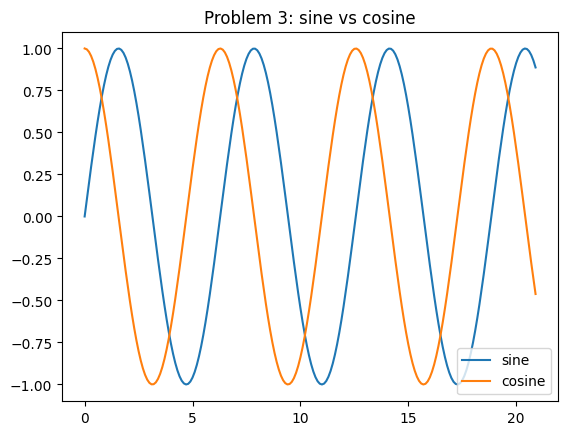

In [467]:
#Your Solution
# I wnated to use different method in this subproblem
# fig (an an instance of the class plt.Figure) can be thought as a single cointainer
# containing all the objects represnting axes, graphics, text, labels
# plt.subplots creates and returns two objects!
# Figure: Class: matplotlib.figure.Figure (Represents: the entire canvas) 
# Axes: Class: matplotlib.axes.Axes (Represents: a single plot)
# 
numbers = np.arange(0,21,.1)
fig, ax = plt.subplots(1,1) 
ax.plot(numbers, np.sin(numbers), label = "sine")
ax.plot(numbers, np.cos(numbers), label = "cosine")
ax.legend()
ax.set_title("Problem 3: sine vs cosine")
plt.show()

**Plot 4:**

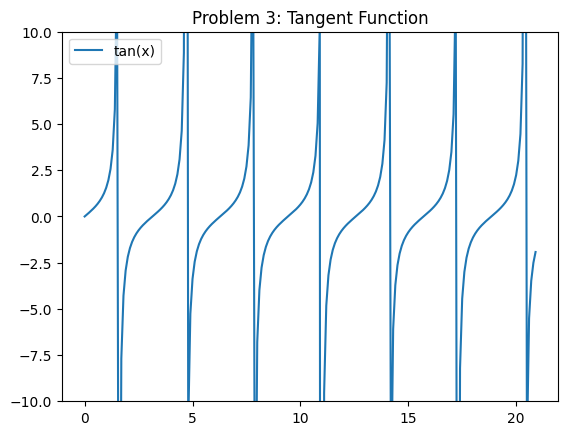

In [468]:
#Your Solution
numbers = np.arange(0,21,.1)
fig, ax = plt.subplots(1,1)
ax.plot(numbers, np.sin(numbers)/np.cos(numbers), label = "tan(x)")
ax.set_ylim(-10, 10) # very large numbers where cosine is close to zero
ax.legend()
ax.set_title("Problem 3: Tangent Function")
plt.show()

**Problem 4**

**Concepts:** *matplotlib, bar chart*

**Task:**

Use the provided lists representing fruit consumption over several days.

Create the following visualizations:

1. A **stacked bar chart** showing strawberry and banana consumption.
2. Two **separate bar charts using subplots**:
* One chart for strawberries (red)
* One chart for bananas (yellow)

Each chart should include:
* a title
* a legend

In [469]:
# STARTER CODE; DO NOT CHANGE
days = range(10)
strawberries = [1, 2, 2, 4, 2, 5, 6, 5, 6, 8]
bananas = [1, 1, 1, 2, 2, 2, 3, 3, 3, 4]


**Plot 1: Stacked Bar Chart**

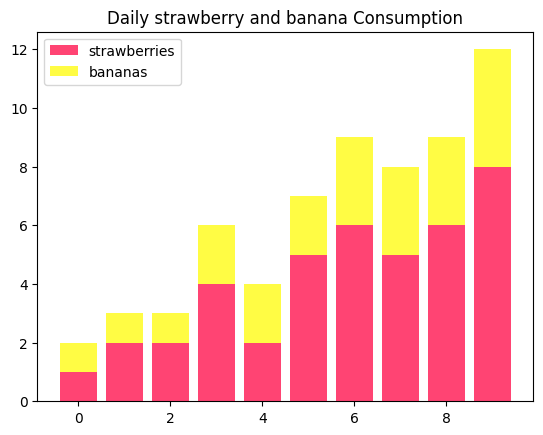

In [470]:
#Your Solution
fig, ax = plt.subplots(1,1) 
ax.bar(days, strawberries, label="strawberries", color="#FF4473" )
ax.bar(days, bananas, label="bananas", color="#FFFC44", bottom = strawberries)
ax.legend()
ax.set_title("Daily strawberry and banana Consumption")
plt.show()
 

**Plot 2: Separate Bar Chart**

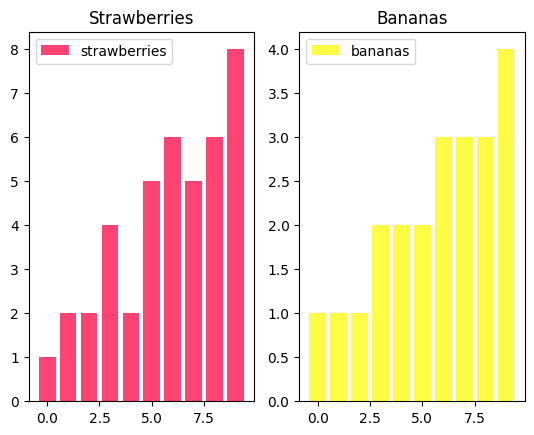

In [471]:
#Your Solution
fig, ax = plt.subplots(1,2)

ax[0].bar(days, strawberries, label="strawberries", color="#FF4473")
ax[0].legend()
ax[0].set_title("Strawberries")

ax[1].bar(days, bananas, label="bananas", color="#FFFC44")
ax[1].legend()
ax[1].set_title("Bananas")
plt.show()

**Problem 5**

**Concepts:** *matplotlib, bar chart*

**Task:**

Using the same fruit consumption data from Problem 4, create a **grouped bar chart**.

Your chart should:
1. Display strawberries (red) and bananas (yellow) side-by-side for each day.
2. Use a bar width to offset the second set of bars.
3. Label the x-axis with the day numbers.
4. Include:
    * axis labels
    * a title
    * a legend

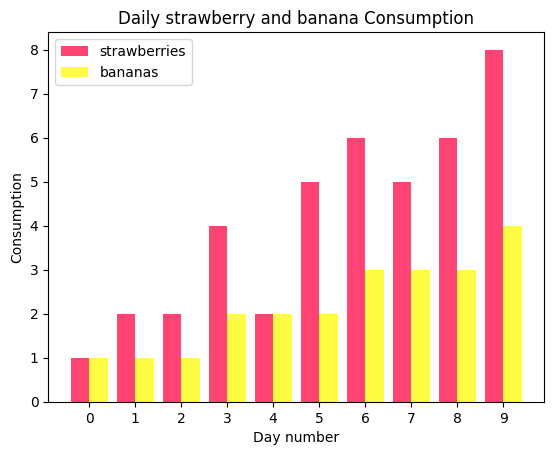

In [472]:
# STARTER CODE; DO NOT CHANGE
days = range(10)
strawberries = [1, 2, 2, 4, 2, 5, 6, 5, 6, 8]
bananas = [1, 1, 1, 2, 2, 2, 3, 3, 3, 4]

#Your Solution
width = 0.4  # width of each bar
days = np.arange(10)
fig, ax = plt.subplots(1,1) 
ax.bar(days - width/2, strawberries, width, label="strawberries", color="#FF4473")
ax.bar(days + width/2, bananas, width, label="bananas", color="#FFFC44")
ax.legend()
ax.set_title("Daily strawberry and banana Consumption")
ax.set_xlabel("Day number")
ax.set_ylabel("Consumption")
ax.set_xticks(days)
plt.show()


**Problem 6**

**Concepts:** *matplotlib, scatter plot*


**Task:**

Create a scatter plot that displays the points of a **unit circle**.

Steps:

1. Generate `x` values between **0 and 1**.
2. Compute the corresponding `y` values using the circle equation:

$$y = sqrt(1 − x²)$$

3. Reflect the points across all four quadrants so that the full circle is drawn.
4. Plot the points using `plt.scatter`.

Set the figure size to **(5,5)** so the circle appears correctly proportioned.

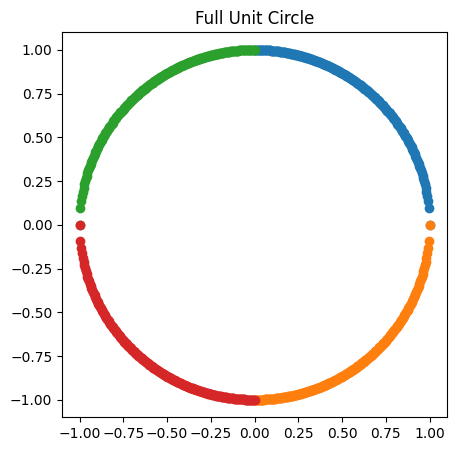

In [473]:
#Your Solution
x = np.linspace(0, 1, 224)
y = np.sqrt(1-x**2)

fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(x, y)
ax.scatter(x, -y)
ax.scatter(-x, y)
ax.scatter(-x,-y)

ax.set_aspect('equal')
ax.set_title("Full Unit Circle")
plt.show()

**Problem 7**

**Concepts:** *matplotlib, scatter plot*

**Task:**

Create a scatter plot using the provided `x_data` and `y_data`.

Plot the data **four different ways on the same chart**:
1. Original values `(x, y)`
2. Horizontal reflection `(-x, y)`
3. Vertical reflection `(x, -y)`
4. Reflection across both axes `(-x, -y)`

Add:
* a legend
* a chart title

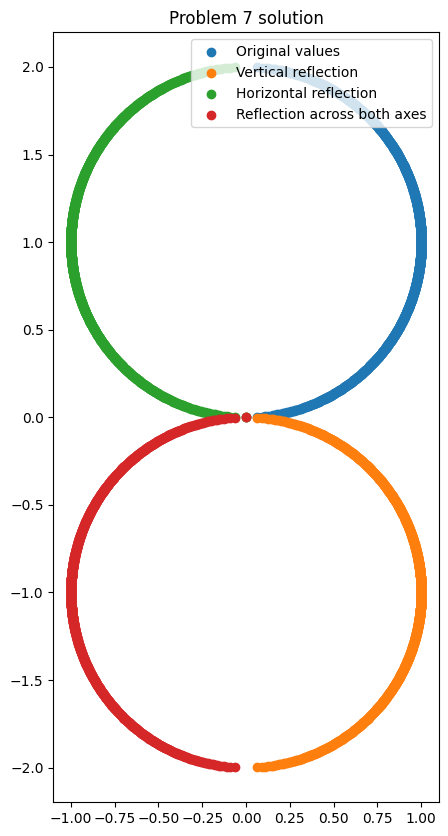

In [474]:
# STARTER CODE; DO NOT CHANGE

y_data = [i / 500 for i in range(1000)]
x_data = [math.sqrt(1 - (y - 1)**2) for y in y_data]


#Your Solution

neg_y_data = [-i for i in y_data]
neg_x_data = [-i for i in x_data]

fig, ax = plt.subplots(figsize = (10,10) )
ax.scatter(x_data, y_data, label = "Original values")
ax.scatter(x_data, neg_y_data, label = "Vertical reflection")
ax.scatter(neg_x_data, y_data, label = "Horizontal reflection")
ax.scatter(neg_x_data, neg_y_data, label = "Reflection across both axes")
ax.legend()
ax.set_title ("Problem 7 solution")
ax.set_aspect('equal')

plt.show()



**Problem 8**

**Concepts:** *matplotlib, scatter plot*

**Task:**

Create a scatter plot that produces a **spiral or tornado-like pattern**.

Steps:
1. Generate a list of radius values that gradually increase so the points move farther away from the center over time.
2. Use a sequence of angle values so that each point rotates a little more than the previous one.
3. Compute the x-coordinates by multiplying each radius value by the cosine of its angle.
4. Compute the y-coordinates by multiplying each radius value by the sine of its angle.
5. Use plt.scatter() to plot the (x, y) points.
6. Add a title to the chart.



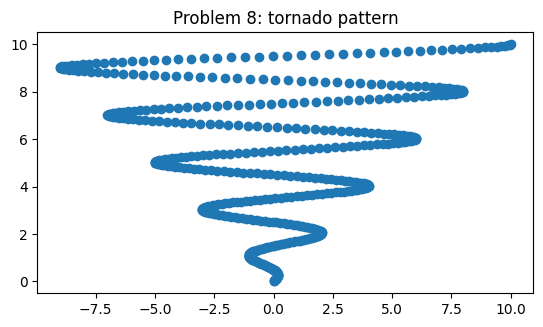

In [475]:
#Your Solution
# These arrays should have compatible lenght. 10 pi equals 5 full runs. 
# Pi radians -> 180 degrees (an angle whose size is pi)
# To get tornado shape, I should not multiply r by sin(theta).
theta = np.linspace(0, 10 * np.pi, 500)
r = np.linspace(0, 10, 500)
# x is equal rcos(theta)
x = r * np.cos(theta)
# y is equal r * np.sin(theta)
y = r # * np.sin(theta)

fig, ax = plt.subplots()
ax.scatter(x,y)
ax.set_title("Problem 8: tornado pattern")
ax.set_aspect('equal')
plt.show()

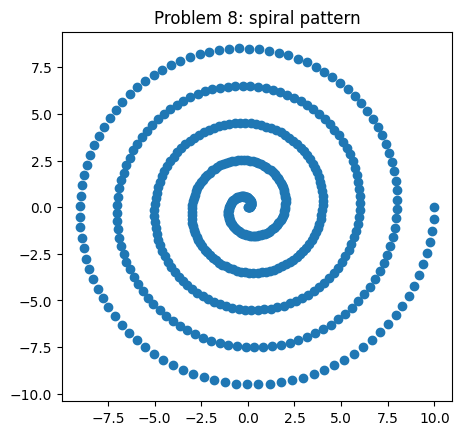

In [476]:
# If I multiply cos according to the instruction I will get spiral, not tornado.

theta_2 = np.linspace(0, 10 * np.pi, 500)
r_2 = np.linspace(0, 10, 500)
# x is equal rcos(theta)
x_2 = r_2 * np.cos(theta_2)
# y is equal r * np.sin(theta)
y_2 = r_2 * np.sin(theta_2) # To get spiral shape, I should multiply r by sin(theta).

fig, ax = plt.subplots()
ax.scatter(x_2,y_2)
ax.set_title("Problem 8: spiral pattern")
ax.set_aspect('equal')
plt.show()

**Problem 9**

**Concepts:** *reading CSV file, scatter plot*

**Task:**

Using the helper function `read_csv_to_dict`, read a dataset stored in `p9_data.csv` containing two numerical variables.

The dataset contains the following columns:

* `dataset` (string label)

* `x` (numerical variable)

* `y` (numerical variable)

Create a scatter plot using the **x** and **y** values for the dataset.

Your plot should include:
* x-axis label
* y-axis label
* title

The goal is to visualize how the two variables relate to each other.

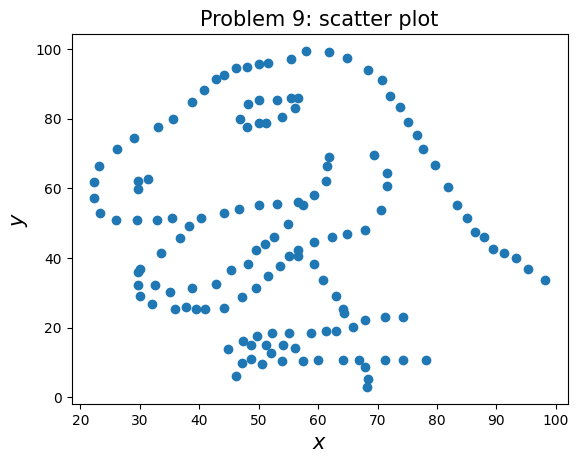

In [477]:
#Your Solution

dataset = read_csv_to_dict("p9_data.csv")

x = dataset["x"]
y = dataset["y"]

fig, ax = plt.subplots()
ax.scatter(x,y)

ax.set_xlabel('$x$', fontsize=15)
ax.set_ylabel('$y$', fontsize=15)
ax.set_title('Problem 9: scatter plot', fontsize=15)

plt.show()

**Problem 10**

**Concepts:** *reading CSV file, line graph*

**Task:**

Write a function:

`create_line_graph(filename, column_name)`

Your function should:
1. Read the CSV file using `read_csv_to_dict`.
2. Verify the specified column exists.
3. Convert the column values to floats.
4. Plot the values as a **line graph**.

Your graph should include:
* a title
* x-axis labeled **Day Number**
* y-axis labeled with the column name

In [478]:
#Your Solution
def create_line_graph(filename, column_name):
    ''' 
    A function create_line_graph() reads a CSV file and plots the values as a line graph.
    '''
    dataset = read_csv_to_dict(filename)
    
    if column_name in dataset.keys():
        col = [float(x) for x in dataset[column_name]]

        plt.plot(col)
        plt.title("Problem 10: line graph")
        plt.xlabel("Day Number")
        plt.ylabel(column_name)
        plt.show()
    

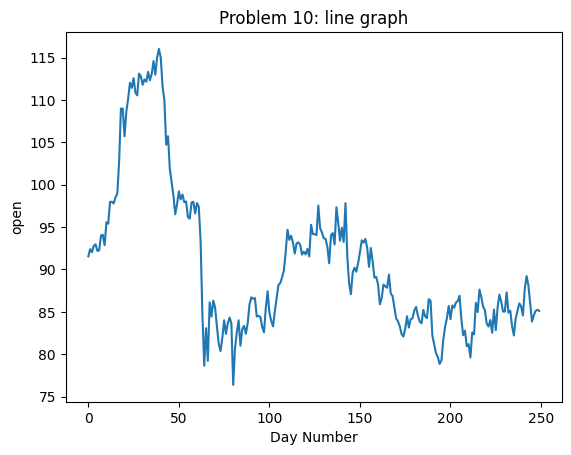

In [479]:
create_line_graph("SBUX.csv", "open")

**Problem 11**

**Concepts:** *reading CSV file, histogram*

**Task:**

Write a function:

`create_histogram(filename, column_name)`

Your function should:
1. Read the CSV file using `read_csv_to_dict`.
2. Convert the selected column to numeric values.
3. Create a histogram of the data.

Requirements:
* Use **at least 10 bins**.
* Add a title showing the column name.

The histogram should display the distribution of values in the selected column.

In [480]:
#Your Solution
def create_histogram(filename, column_name):
    ''' 
    The function `create_histogram()` reads a CSV file, converts the selected column
    to numeric values, and plots a histogram of the data.
    '''
    dataset = read_csv_to_dict(filename)
    
    if column_name in dataset.keys():
        col = [float(x) for x in dataset[column_name]]

        plt.hist(col, bins = 10)
        plt.title(f"Problem 11: histogram\nColumn name: {column_name}")
        plt.xlabel(column_name)
        plt.ylabel("Frequency")
        plt.show()

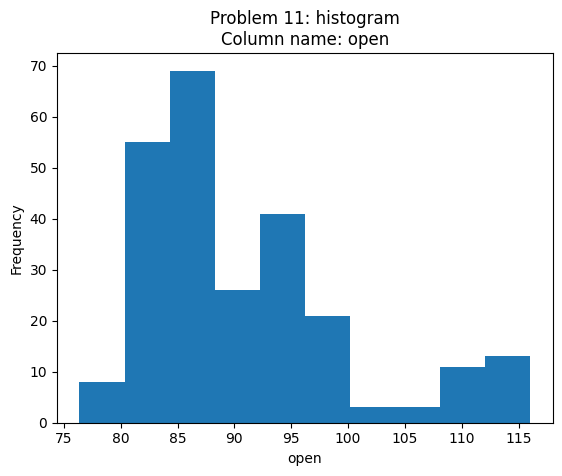

In [481]:
create_histogram("SPY.csv", "open")

**Problem 12**

**Concepts:** *reading CSV file, pie chart*

**Task:**

Write a function:

`create_pie_chart(filename, column_name)`

Your function should:
1. Read the CSV file using `read_csv_to_dict`.
2. Convert the selected column to numeric values.
3. Compute the **mean value** of the column.
4. Determine:
* the percentage of values **greater than the mean**
* the percentage **less than or equal to the mean**

Create a pie chart displaying these two proportions.

Include:
* labels
* percentages
* chart title

In [482]:
#Your Solution
def create_pie_chart(filename, column_name):
    ''' 
    A function create_pie_chart() reads a CSV file and creates a pie chart displaying the proportions of values.
    '''
    dataset = read_csv_to_dict(filename)
    col = np.array([float(v) for v in dataset[column_name]])
    col_mean = np.mean(col)
    greater_than_mean = np.mean(col > col_mean)
    less_or_equal_mean = sum(col <= col_mean) / len(col) # another approach just for practise

    fig, ax = plt.subplots()
    ax.pie([greater_than_mean, less_or_equal_mean], 
           labels = ["values greater than the mean", "values less than or equal to the mean"],
           autopct='%1.1f%%')
    ax.set_title("Problem 12: pie chart")
    plt.show()



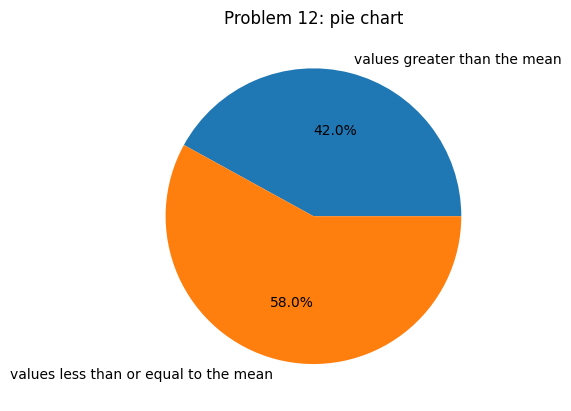

In [483]:
# ar = [1,2,3,4]
# ar_mean = np.mean(ar)
# sum(ar <= ar_mean) / len(ar)
create_pie_chart("SBUX.csv", "close")

**Problem 13**

**Concepts:** *reading CSV file, scatter plot*

**Task:**

Write a function:

`create_scatter_plot(filename, x_column, y_column)`

Your function should:
1. Read the CSV file using `read_csv_to_dict`.
2. Extract the specified columns.
3. Convert the values to floats.
4. Create a scatter plot showing the relationship between the two variables.

Include:
* x-axis label
* y-axis label
* title

In [484]:
#Your Solution
def create_scatter_plot(filename, x_column, y_column):
    ''' 
    A function create_scatter_plot() reads a CSV file and creates a scatter plot showing the relationship between the two variables.
    '''
    dataset = read_csv_to_dict(filename)
    
    X = dataset[x_column]
    y = dataset[y_column]
    # values from CSV are mostly strings. isinstance gave me an error because of that

    X_float = [float(v) for v in X ] # if isinstance(v, (int, float))
    y_float = [float(v) for v in y ]

    fig, ax = plt.subplots()
    ax.scatter(X_float,y_float)

    ax.set_xlabel(x_column, fontsize=15)
    ax.set_ylabel(y_column, fontsize=15)
    ax.set_title('Problem 13: scatter plot', fontsize=15)

    plt.show()
    

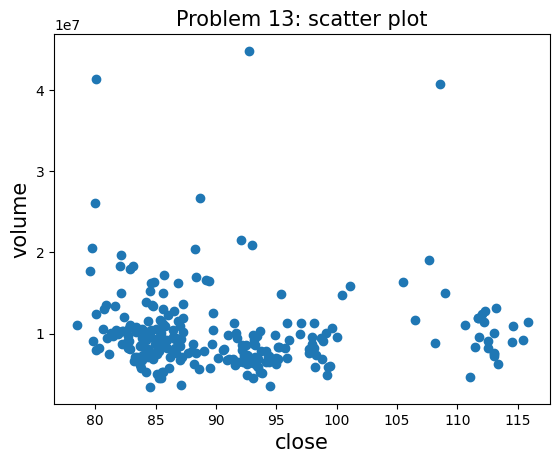

In [485]:
create_scatter_plot("SPY.csv", "close", "volume")